In [1]:
import random
import torch
import numpy as np

# for easier reading np
np.set_printoptions(precision=3,suppress=True)

In [2]:
from sklearn import datasets
iris = datasets.load_iris()
X = torch.tensor(iris.data[:, :3], dtype=torch.float32)  # we only take the first three features.
y = torch.tensor(iris.data[:, 3], dtype=torch.float32)   # we use the fourth feature as the target.

# Uncomment this line for problem 2 (logistic regression)
# X = torch.tensor(iris.data, dtype=torch.float32)
# y = torch.tensor(iris.target == 2, dtype=torch.float32)

In [3]:
# Partition the data into Training and Testing (80:20 split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=0)

print('X_train', X_train.shape)
print('X_test', X_test.shape)

X_train torch.Size([120, 3])
X_test torch.Size([30, 3])


In [4]:
# Reading the dataset
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    
    # The examples are read at random, in no particular order
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        j = indices[i:i + batch_size]
        yield features[j], labels[j]

# Check data reader
for X_batch, y_batch in data_iter(batch_size=10, features=X_train, labels=y_train):
    print('X_batch', X_batch.shape, X_batch[0])
    print('y_batch', y_batch.shape, y_batch[0])
    break

X_batch torch.Size([10, 3]) tensor([4.8000, 3.4000, 1.6000])
y_batch torch.Size([10]) tensor(0.2000)


In [5]:
# Initializing Model Parameters
w = torch.nn.Parameter(data=torch.zeros((3, 1)), requires_grad=True)
torch.nn.init.normal_(w, mean=0, std=0.01)
b = torch.nn.Parameter(data=torch.zeros((1, 1)), requires_grad=True)
print('w', w)
print('b', b)

w Parameter containing:
tensor([[0.0142],
        [0.0036],
        [0.0048]], requires_grad=True)
b Parameter containing:
tensor([[0.]], requires_grad=True)


In [6]:
# Defining the Model
def linreg(X, w, b): 
    """The linear regression model."""
    return X@w + b

# Check model
for X_batch, y_batch in data_iter(batch_size=10, features=X_train, labels=y_train):
    out_batch = linreg(X_batch, w, b)
    print('X_batch', X_batch.shape, X_batch[0])
    print('out_batch', out_batch.shape, out_batch[0])
    break

X_batch torch.Size([10, 3]) tensor([5.0000, 3.3000, 1.4000])
out_batch torch.Size([10, 1]) tensor([0.0897], grad_fn=<SelectBackward0>)


In [7]:
# Defining the Loss Function
def squared_loss(y_hat, y):
    """Squared loss."""
    return torch.mean((y_hat - y.view(y_hat.shape))**2 / 2)

def rsquare(y_hat, y):
    mse = torch.sum((y - yhat)**2)
    var = torch.sum((y - torch.mean(y_test))**2)
    return 1 - mse / var

# Check loss
err = squared_loss(torch.tensor([1, 2, 3]), torch.tensor([3, 2, 1]))
print('err =', err)

err = tensor(1.3333)


In [8]:
# Defining the Optimization Algorithm
def sgd(params, grads, lr):
    """Minibatch stochastic gradient descent."""
    for p, g in zip(params, grads):
        p.data -= lr * g

**Training**

In [9]:
lr = 0.01
batch_size = 10
num_epochs = 50
net = linreg
loss = squared_loss

In [11]:
# Initialize the parameters of the model
torch.nn.init.normal_(w, mean=0, std=0.01)
torch.nn.init.zeros_(b)
# TODO: problem 1b
test_Rqs = []
train_Rqs = []
for epoch in range(num_epochs):
    # Evaluate model
    with torch.no_grad():
        yhat = net(X_test, w, b)[:, 0]
        R_sq = rsquare(yhat, y_test)
        test_l = loss(yhat, y_test)
        print(f'epoch {epoch:03d}, test loss {float(test_l):.5f}, Rsquare {R_sq:.3f}') 
        
        test_Rqs.append(R_sq.item())
        
    with torch.no_grad():
        yhat = net(X_train, w, b)[:, 0]
        R_sq = rsquare(yhat, y_train)
        train_Rqs.append(R_sq.item())

    # Train for one epoch
    for X_batch, y_batch in data_iter(batch_size=10, features=X_train, labels=y_train):
        # Use model to compute predictions
        yhat = net(X_batch, w, b)
        l = loss(yhat, y_batch)  # Minibatch loss in `X_batch` and `y_batch`
        
        # Compute gradients by back propagation
        l.backward()

        # Update parameters using their gradient
        sgd([w, b], [w.grad, b.grad], lr)

        # Reset gradients
        w.grad = b.grad = None

epoch 000, test loss 0.75285, Rsquare -2.136
epoch 001, test loss 0.10268, Rsquare 0.572
epoch 002, test loss 0.07567, Rsquare 0.685
epoch 003, test loss 0.05720, Rsquare 0.762
epoch 004, test loss 0.04980, Rsquare 0.793
epoch 005, test loss 0.04008, Rsquare 0.833
epoch 006, test loss 0.03551, Rsquare 0.852
epoch 007, test loss 0.03387, Rsquare 0.859
epoch 008, test loss 0.03279, Rsquare 0.863
epoch 009, test loss 0.03527, Rsquare 0.853
epoch 010, test loss 0.03157, Rsquare 0.868
epoch 011, test loss 0.03141, Rsquare 0.869
epoch 012, test loss 0.03226, Rsquare 0.866
epoch 013, test loss 0.03149, Rsquare 0.869
epoch 014, test loss 0.03515, Rsquare 0.854
epoch 015, test loss 0.03171, Rsquare 0.868
epoch 016, test loss 0.03276, Rsquare 0.864
epoch 017, test loss 0.03214, Rsquare 0.866
epoch 018, test loss 0.03376, Rsquare 0.859
epoch 019, test loss 0.03171, Rsquare 0.868
epoch 020, test loss 0.03282, Rsquare 0.863
epoch 021, test loss 0.03681, Rsquare 0.847
epoch 022, test loss 0.04056, R

In [12]:
# R2 = 1 - MSE/var(y)
print('Intercept = ', b.detach().numpy())
print('Coefficients = \n', w.detach().numpy())

with torch.no_grad():
    yhat = net(X_train, w, b)[:, 0]
    mse = torch.sum((y_train - yhat)**2)
    var = torch.sum((y_train - torch.mean(y_train))**2)
    R_sq_train = 1 - mse / var
    
    yhat = net(X_test, w, b)[:, 0]
    mse = torch.sum((y_test - yhat)**2)
    var = torch.sum((y_test - torch.mean(y_test))**2)
    R_sq_test = 1 - mse / var
    
print('Train R square = ', format(R_sq_train.numpy(),".3f"))
print('Test R square = ', format(R_sq_test.numpy(),".3f"))

Intercept =  [[-0.044]]
Coefficients = 
 [[-0.048]
 [-0.037]
 [ 0.427]]
Train R square =  0.933
Test R square =  0.876


## Problem 4b

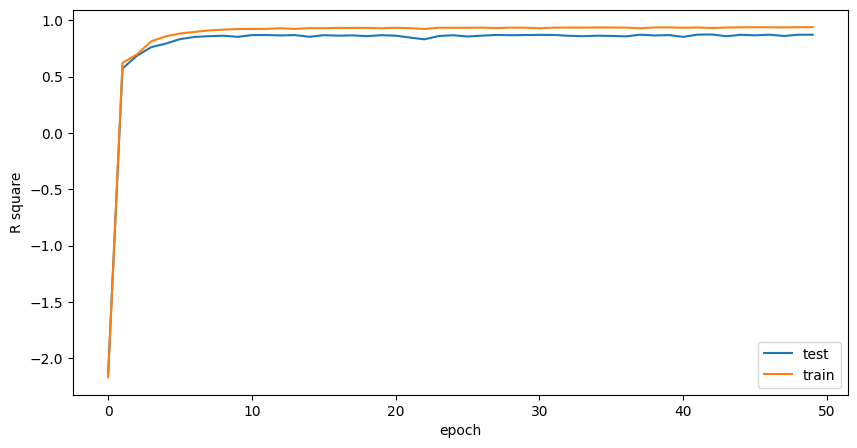

In [13]:
# draw the plot: R square vs epoch
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(test_Rqs, label='test')
plt.plot(train_Rqs, label='train')
plt.xlabel('epoch')
plt.ylabel('R square')
plt.legend()
plt.show()
# observation: As the epoch increases, the R square of test data increases; the R square of the train data also increases, but the increase is not obvious.


## Problem 4c

epoch 000, test loss 0.81625, Rsquare -2.400
epoch 001, test loss 0.07049, Rsquare 0.706
epoch 002, test loss 0.05481, Rsquare 0.772
epoch 003, test loss 0.10899, Rsquare 0.546
epoch 004, test loss 0.07660, Rsquare 0.681
epoch 005, test loss 0.06227, Rsquare 0.741
epoch 006, test loss 0.05614, Rsquare 0.766
epoch 007, test loss 0.04490, Rsquare 0.813
epoch 008, test loss 0.03829, Rsquare 0.840
epoch 009, test loss 0.05033, Rsquare 0.790
epoch 010, test loss 0.04256, Rsquare 0.823
epoch 011, test loss 0.13762, Rsquare 0.427
epoch 012, test loss 0.07935, Rsquare 0.669
epoch 013, test loss 0.03319, Rsquare 0.862
epoch 014, test loss 0.03184, Rsquare 0.867
epoch 015, test loss 0.05703, Rsquare 0.762
epoch 016, test loss 0.03245, Rsquare 0.865
epoch 017, test loss 0.03130, Rsquare 0.870
epoch 018, test loss 0.13848, Rsquare 0.423
epoch 019, test loss 0.03009, Rsquare 0.875
epoch 020, test loss 0.03423, Rsquare 0.857
epoch 021, test loss 0.25018, Rsquare -0.042
epoch 022, test loss 0.09416, 

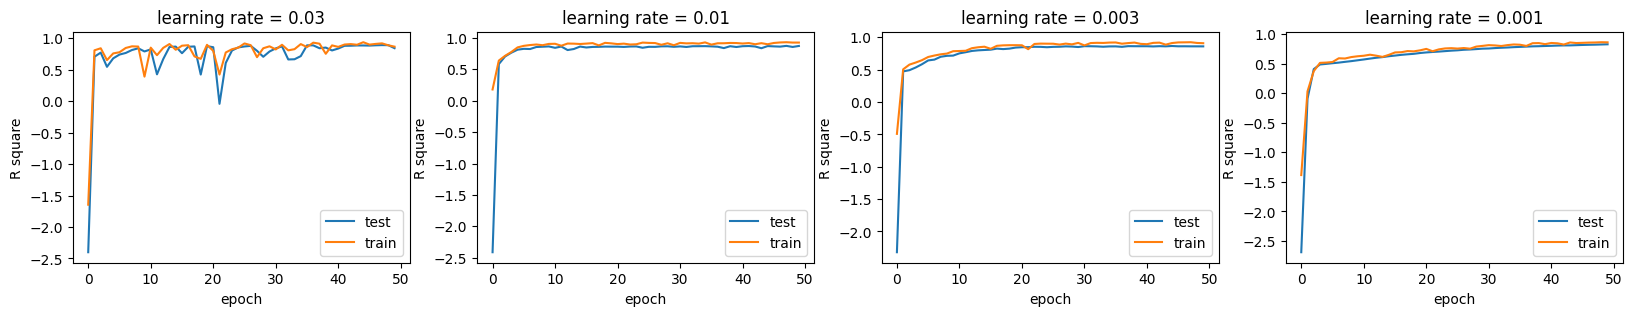

In [14]:
# Show the plot: R square vs epoch under different learning rate
performance = {}
for lr in [0.03,0.01,0.003,0.001]:
    batch_size = 10
    num_epochs = 50
    net = linreg
    loss = squared_loss

    # Initialize the parameters of the model
    torch.nn.init.normal_(w, mean=0, std=0.01)
    torch.nn.init.zeros_(b)
    # TODO: problem 1b
    test_Rqs = []
    train_Rqs = []
    for epoch in range(num_epochs):
        train_rq = []
        # Evaluate model
        with torch.no_grad():
            yhat = net(X_test, w, b)[:, 0]
            mse = torch.sum((y_test - yhat)**2)
            var = torch.sum((y_test - torch.mean(y_test))**2)
            R_sq = 1 - mse / var
            test_l = loss(yhat, y_test)
            # TODO: problem 1b
            test_Rqs.append(R_sq.item())
            print(f'epoch {epoch:03d}, test loss {float(test_l):.5f}, Rsquare {R_sq:.3f}') 

        # Train for one epoch
        for X_batch, y_batch in data_iter(batch_size=10, features=X_train, labels=y_train):
            # Use model to compute predictions
            yhat = net(X_batch, w, b)
            l = loss(yhat, y_batch)  # Minibatch loss in `X_batch` and `y_batch`
            mse = torch.sum((y_batch - yhat[:, 0])**2)
            var = torch.sum((y_batch - torch.mean(y_batch))**2)
            # TODO: problem 1b
            train_rq.append((1 - mse/var).item())
            # Compute gradients by back propagation
            l.backward()

            # Update parameters using their gradient
            sgd([w, b], [w.grad, b.grad], lr)

            # Reset gradients
            w.grad = b.grad = None
        train_Rqs.append(np.mean(train_rq))
    performance[lr] = [test_Rqs, train_Rqs]


# Draw the plot: R square vs epoch (different learning rate)
# r2 is plotted for each learning rate in different subplots
import matplotlib.pyplot as plt
num_lr = len(performance)
fig, axs = plt.subplots(1, num_lr, figsize=(20, 3))

for idx, (lr, Rqs) in enumerate(performance.items()):
    figure_id = idx + 1
    axs[figure_id - 1].plot(Rqs[0], label='test')
    axs[figure_id - 1].plot(Rqs[1], label='train')
    axs[figure_id - 1].set_xlabel('epoch')
    axs[figure_id - 1].set_ylabel('R square')
    axs[figure_id - 1].legend()
    axs[figure_id - 1].set_title('learning rate = ' + str(lr))


## Problem 4d

In [ ]:
# Show the plot: R square vs epoch under different batch size
performance = {}
for batch_size in [1,3,10,30,100]:
    lr = 0.003
    num_epochs = 50
    net = linreg
    loss = squared_loss

    # Initialize the parameters of the model
    torch.nn.init.normal_(w, mean=0, std=0.01)
    torch.nn.init.zeros_(b)
    # TODO: problem 1b
    test_Rqs = []
    train_Rqs = []
    for epoch in range(num_epochs):
        train_rq = []
        # Evaluate model
        with torch.no_grad():
            yhat = net(X_test, w, b)[:, 0]
            mse = torch.sum((y_test - yhat)**2)
            var = torch.sum((y_test - torch.mean(y_test))**2)
            R_sq = 1 - mse / var
            test_l = loss(yhat, y_test)
            # TODO: problem 1b
            test_Rqs.append(R_sq.item())
            print(f'epoch {epoch:03d}, test loss {float(test_l):.5f}, Rsquare {R_sq:.3f}') 

        # Train for one epoch
        for X_batch, y_batch in data_iter(batch_size=batch_size, features=X_train, labels=y_train):
            # Use model to compute predictions
            yhat = net(X_batch, w, b)
            l = loss(yhat, y_batch)  # Minibatch loss in `X_batch` and `y_batch`
            mse = torch.sum((y_batch - yhat[:, 0])**2)
            var = torch.sum((y_batch - torch.mean(y_batch))**2)
            # TODO: problem 1b
            train_rq.append((1 - mse/var).item())
            # Compute gradients by back propagation
            l.backward()

            # Update parameters using their gradient
            sgd([w, b], [w.grad, b.grad], lr)

            # Reset gradients
            w.grad = b.grad = None
        train_Rqs.append(np.mean(train_rq))
    performance[batch_size] = [test_Rqs, train_Rqs]


# Draw the plot: R square vs epoch (different learning rate)
# r2 is plotted for each learning rate in different subplots
import matplotlib.pyplot as plt
num_lr = len(performance)
fig, axs = plt.subplots(1, num_lr, figsize=(20, 3))

for idx, (bs, Rqs) in enumerate(performance.items()):
    figure_id = idx + 1
    axs[figure_id - 1].plot(Rqs[0], label='test')
    axs[figure_id - 1].plot(Rqs[1], label='train')
    axs[figure_id - 1].set_xlabel('epoch')
    axs[figure_id - 1].set_ylabel('R square')
    axs[figure_id - 1].legend()
    axs[figure_id - 1].set_title('batch size = ' + str(bs))
